# Model Training

### Import Required Libraries

In [1]:
# Import libraries

import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

### Recreate Generators in Training Notebook

In [2]:
# code

# Dataset Paths

train_dir = "../data/train"
val_dir = "../data/val"

# Image Parameters

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 20

# Data Augmentation

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.8, 1.2],

    fill_mode="nearest"
)

# Test Generator

val_test_datagen = ImageDataGenerator(

    rescale=1./255
)

# Train Data Loader

train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"
)

# Validation Loader

val_generator = val_test_datagen.flow_from_directory(

    val_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"
)


Found 1862 images belonging to 2 classes.
Found 399 images belonging to 2 classes.


### Load the Model

In [3]:
from tensorflow.keras.models import load_model

model = load_model(

    "../models/custom_cnn_initial.keras",
    
    compile=False
)

### Define Training Parameters

In [4]:
# Constant values

EPOCHS = 20

BATCH_SIZE = 32

### Define Callbacks

#### EarlyStopping

In [5]:
# Stops training when validation stops improving.

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

#### ModelCheckpoint

In [6]:
# Automatically saves the best model.

checkpoint = ModelCheckpoint(

    "../models/best_custom_cnn.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)

#### Reduce Learning Rate

In [7]:
# Improves convergence.

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=3,

    min_lr=0.00001
)

### Compiling the model 

In [8]:
# Compiling the model -> as earlier in the loading time, we give set compile=False

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",
    
    metrics=["accuracy"]
)

### Train the Model

In [9]:
# code

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6475 - loss: 10.3753
Epoch 1: val_accuracy improved from None to 0.61404, saving model to ../models/best_custom_cnn.keras

Epoch 1: finished saving model to ../models/best_custom_cnn.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6643 - loss: 10.8086 - val_accuracy: 0.6140 - val_loss: 1.4923 - learning_rate: 0.0010
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.6729 - loss: 7.6833
Epoch 2: val_accuracy did not improve from 0.61404
59/59 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6907 - loss: 5.8625 - val_accuracy: 0.4962 - val_loss: 2.7513 - learning_rate: 0.0010
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7030 - loss: 4.9907
Epoch 3: val_accuracy did not improve from 0.61404
59/59 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6966 - loss: 3.9871 - val_accuracy: 0.3860 - val_loss: 3.3984 - learning_rate: 0.0010
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy

### Save Final Model

In [10]:
# code

model.save(
    "../models/custom_cnn_final.keras"
)

### Plot Training History

#### Accuracy Plot

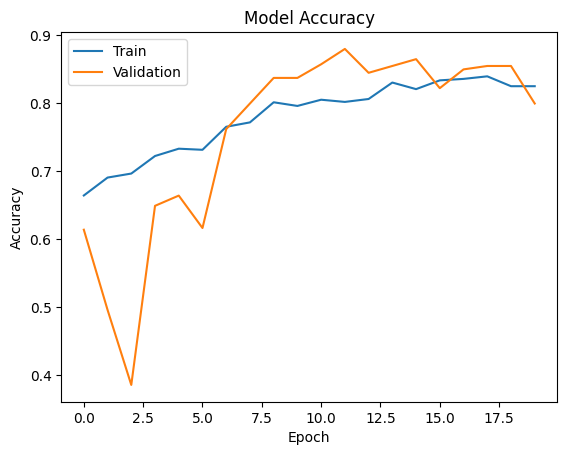

In [11]:
# Accuracy Plot

plt.figure()

plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(
    ["Train", "Validation"]
)

plt.show()

#### Loss Plot

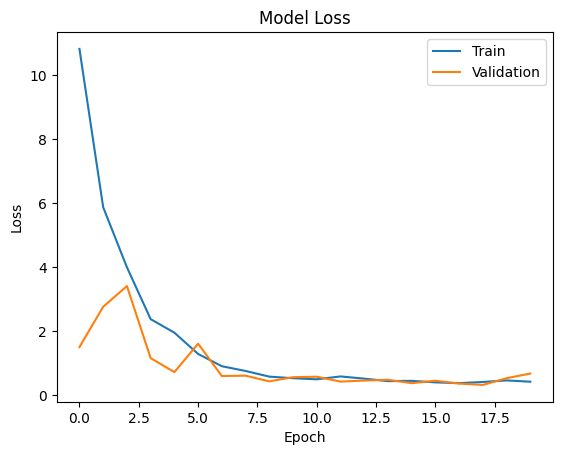

In [12]:
# Loss Plot

plt.figure()

plt.plot(
    history.history["loss"]
)

plt.plot(
    history.history["val_loss"]
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(
    ["Train", "Validation"]
)

plt.show()